In [1]:
import pandas as pd
import importlib
import fairnessinsight

importlib.reload(fairnessinsight)
from fairnessinsight.Datasets.BaseDataset import BaseDataset
from fairnessinsight.PostTrainingBias import PostTrainingBias


In [2]:
bd = BaseDataset()
df = pd.read_csv("datasets/heart.csv")
bd.dataset = df
bd.target = "target"
bd.predicted_attr = "target"
bd.random_state = 0
bd.positive_outcome = 0
bd.protected_attr = ["sex"]
bd.protected_attr_mappings = {"sex": {"Female": [0], "Male": [1]}}

bd.max_iter = 2000
bd.n_estimators = 20
bd.random_state = 0
bd.max_depth = 7
bd.criterion = "entropy"
bd.num_repetitions = 2
        

In [10]:
bd.evaluate_pre_training_metrics("sex", 1, bd.dataset, False)

{'Class Imbalance (sex)': 0.9078341013824884,
 'KL Divergence (sex)': 0.6274338856608355,
 'KS (sex)': 0.45072463768115945,
 'Demographic Disparity (sex)': 0.07953964194373402}

In [4]:
acc, f1 = bd.execute_models()

In [5]:
bd.evaluate_post_training_metrics(bd.protected_attr[0], 1)

{'LogisticRegression': {'DPPL (sex)': -0.443,
  'DI (sex)': 2.081,
  'DCA (sex)': 0.118,
  'DCR (sex)': -1.762},
 'DecisionTreeClassifier': {'DPPL (sex)': -0.369,
  'DI (sex)': 1.933,
  'DCA (sex)': 0.037,
  'DCR (sex)': -0.529},
 'RandomForestClassifier': {'DPPL (sex)': -0.282,
  'DI (sex)': 1.61,
  'DCA (sex)': -0.123,
  'DCR (sex)': -0.341},
 'XGBClassifier': {'DPPL (sex)': -0.314,
  'DI (sex)': 1.668,
  'DCA (sex)': -0.089,
  'DCR (sex)': -1.341}}

In [11]:
import numpy as np

percentages = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9 ]  # 0% to 90% removal
results = []
np.random.seed(bd.random_state)
for pct in percentages:
    df_var = df.copy()
    female_idx = df_var[df_var["sex"] == 0].index
    n_remove = int(len(female_idx) * pct)
    if n_remove > 0:
        idx_remove = np.random.choice(female_idx, n_remove, replace=False)
        df_var = df_var.drop(idx_remove)
    bd.dataset = df_var
    # acc, f1 = bd.execute_models()
    metrics = bd.evaluate_pre_training_metrics("sex", 1, df_var, False)

    results.append({
        "percentage_removed": pct,
        "metrics": metrics,
        # "accuracy": acc,
        # "f1": f1
    })

# Show results
results


[{'percentage_removed': 0.0,
  'metrics': {'Class Imbalance (sex)': 0.36633663366336633,
   'KL Divergence (sex)': 0.20472258782597605,
   'KS (sex)': 0.3007246376811594,
   'Demographic Disparity (sex)': 0.2624505928853755}},
 {'percentage_removed': 0.1,
  'metrics': {'Class Imbalance (sex)': 0.40816326530612246,
   'KL Divergence (sex)': 0.21891361075780147,
   'KS (sex)': 0.3093453273363318,
   'Demographic Disparity (sex)': 0.25953878406708597}},
 {'percentage_removed': 0.2,
  'metrics': {'Class Imbalance (sex)': 0.45774647887323944,
   'KL Divergence (sex)': 0.20998098788509773,
   'KS (sex)': 0.3039713909279127,
   'Demographic Disparity (sex)': 0.24124881740775783}},
 {'percentage_removed': 0.3,
  'metrics': {'Class Imbalance (sex)': 0.5054545454545455,
   'KL Divergence (sex)': 0.2293859931514019,
   'KS (sex)': 0.3154305200341006,
   'Demographic Disparity (sex)': 0.23554376657824933}},
 {'percentage_removed': 0.4,
  'metrics': {'Class Imbalance (sex)': 0.5622641509433962,
   

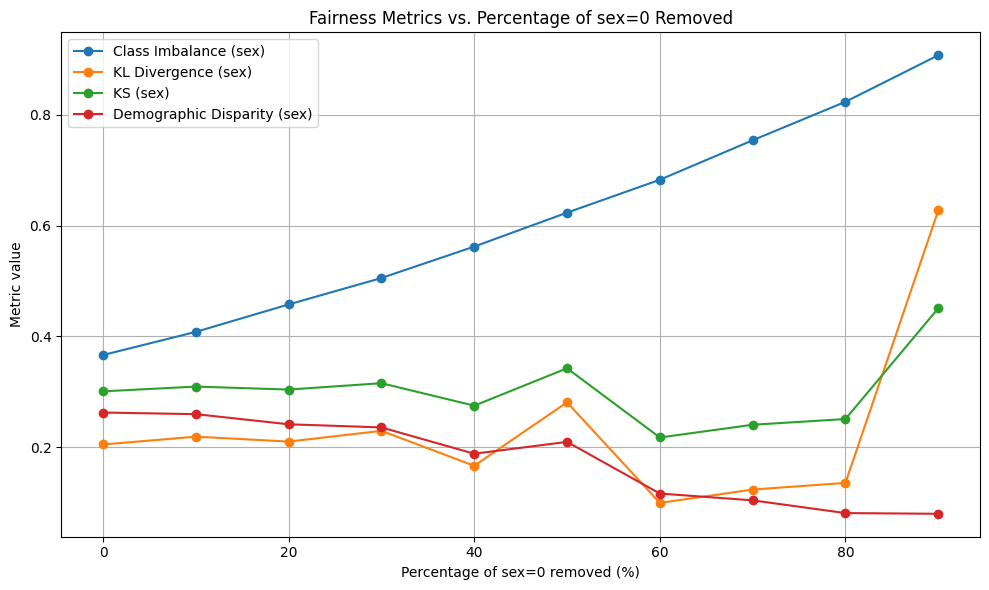

In [12]:
import matplotlib.pyplot as plt

# Extract data for plotting
percentages = [r['percentage_removed']*100 for r in results]
metrics_names = list(results[0]['metrics'].keys())
metrics_data = {name: [r['metrics'][name] for r in results] for name in metrics_names}

plt.figure(figsize=(10, 6))
for name in metrics_names:
    plt.plot(percentages, metrics_data[name], marker='o', label=name)

plt.xlabel('Percentage of sex=0 removed (%)')
plt.ylabel('Metric value')
plt.title('Fairness Metrics vs. Percentage of sex=0 Removed')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# import matplotlib.pyplot as plt

# # Extract data for plotting
# percentages = [r['percentage_removed']*100 for r in results]
# model_names = list(results[0]['accuracy'].keys())
# acc_data = {name: [r['accuracy'][name] for r in results] for name in model_names}

# plt.figure(figsize=(10, 6))
# for name in model_names:
#     plt.plot(percentages, acc_data[name], marker='o', label=name)

# plt.xlabel('Percentage of sex=0 removed (%)')
# plt.ylabel('Accuracy (%)')
# plt.title('Model Accuracy vs. Percentage of sex=0 Removed')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [14]:
# import matplotlib.pyplot as plt

# # Extract data for plotting
# percentages = [r['percentage_removed']*100 for r in results]
# model_names = list(results[0]['f1'].keys())
# f1_data = {name: [r['f1'][name] for r in results] for name in model_names}

# plt.figure(figsize=(10, 6))
# for name in model_names:
#     plt.plot(percentages, f1_data[name], marker='o', label=name)

# plt.xlabel('Percentage of sex=0 removed (%)')
# plt.ylabel('F1 Score')
# plt.title('Model F1 Score vs. Percentage of sex=0 Removed')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()